# Task 3: Heart Disease Prediction

## Objective
Build a classification model to predict whether a person is at risk of heart disease
based on their health indicators.

## Dataset
- **Name**: Heart Disease UCI Dataset
- **Source**: Kaggle
- **Rows**: 303 patients | **Columns**: 14 features
- **Target**: `target` — 1 = Heart Disease Present, 0 = Not Present

## Features Description
| Feature    | Description                                      |
|------------|--------------------------------------------------|
| age        | Age of the patient                               |
| sex        | Sex (1 = male, 0 = female)                       |
| cp         | Chest pain type (0–3)                            |
| trestbps   | Resting blood pressure (mm Hg)                   |
| chol       | Serum cholesterol (mg/dl)                        |
| fbs        | Fasting blood sugar > 120 mg/dl (1 = true)       |
| restecg    | Resting ECG results (0–2)                        |
| thalach    | Maximum heart rate achieved                      |
| exang      | Exercise induced angina (1 = yes)                |
| oldpeak    | ST depression induced by exercise                |
| slope      | Slope of peak exercise ST segment               |
| ca         | Number of major vessels (0–3)                    |
| thal       | Thalassemia (1 = normal, 2 = fixed, 3 = reversible)|
| target     | 1 = Heart Disease, 0 = No Heart Disease          |

## Models Used
- Logistic Regression
- Decision Tree Classifier

## Goal
Train, evaluate, and compare both models using accuracy, confusion matrix, and ROC-AUC.

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('heart.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

Shape: (303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# ── Data types and non-null counts ────────────────────────────────────────────
print("Dataset Info:")
df.info()
# ── Summary statistics ────────────────────────────────────────────────────────
print("Summary Statistics:")
df.describe()
# ── Check for missing values ──────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
Summary Statistics:
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
t

In [5]:
# ── Handle missing values (if any) ───────────────────────────────────────────
# Fill numeric columns with median (safer than mean for medical data)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled missing values in '{col}' with median")

# Check for duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows found: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

print(f"\nClean dataset shape: {df.shape}")
print("\nNo missing values remaining:", df.isnull().sum().sum() == 0)


Duplicate rows found: 1
Duplicates removed.

Clean dataset shape: (302, 14)

No missing values remaining: True


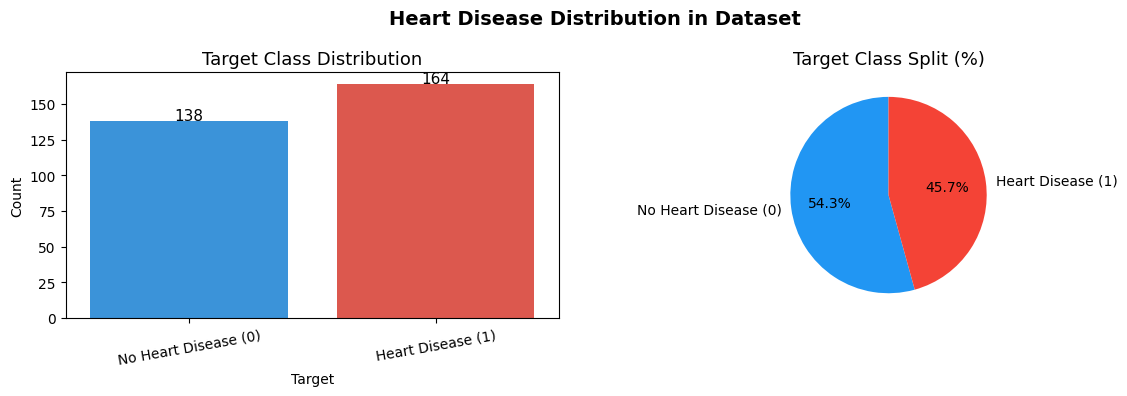

In [6]:
# ── Class balance check ───────────────────────────────────────────────────────
target_counts = df['target'].value_counts()
labels = ['No Heart Disease (0)', 'Heart Disease (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='target', data=df, palette=['#2196F3', '#F44336'], ax=axes[0])
axes[0].set_title('Target Class Distribution', fontsize=13)
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels, rotation=10)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts, labels=labels, autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Target Class Split (%)', fontsize=13)

plt.suptitle('Heart Disease Distribution in Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

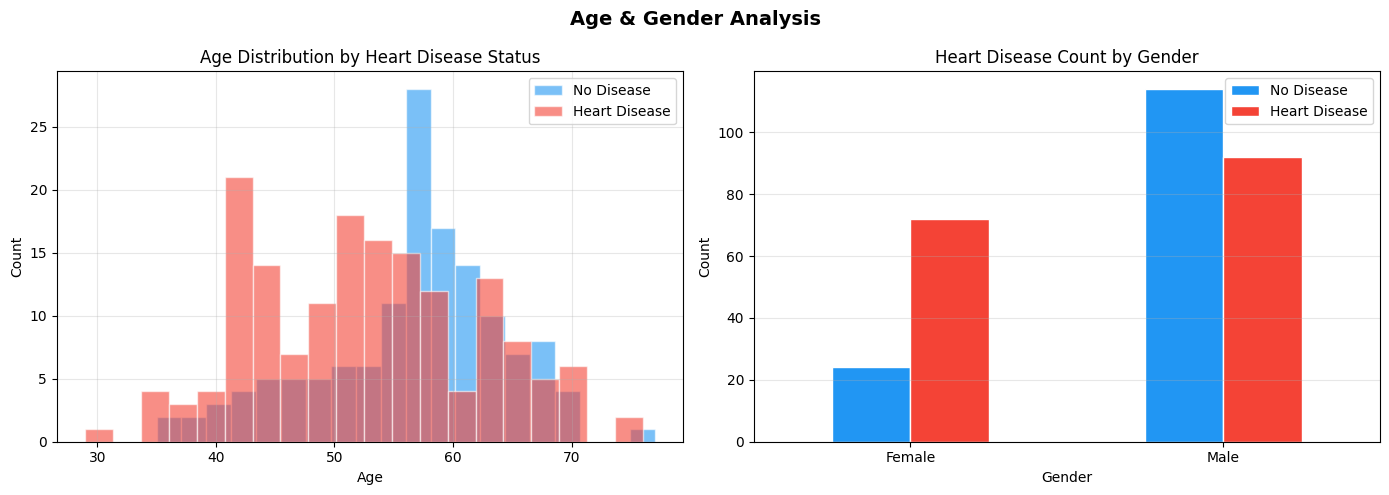

In [7]:
# ── Age distribution by target ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by target
for target_val, color, label in zip([0, 1], ['#2196F3', '#F44336'],
                                     ['No Disease', 'Heart Disease']):
    axes[0].hist(df[df['target'] == target_val]['age'],
                 bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Heart Disease Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gender vs Heart Disease
gender_target = df.groupby(['sex', 'target']).size().unstack()
gender_target.index = ['Female', 'Male']
gender_target.columns = ['No Disease', 'Heart Disease']
gender_target.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'],
                   edgecolor='white', rot=0)
axes[1].set_title('Heart Disease Count by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Age & Gender Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

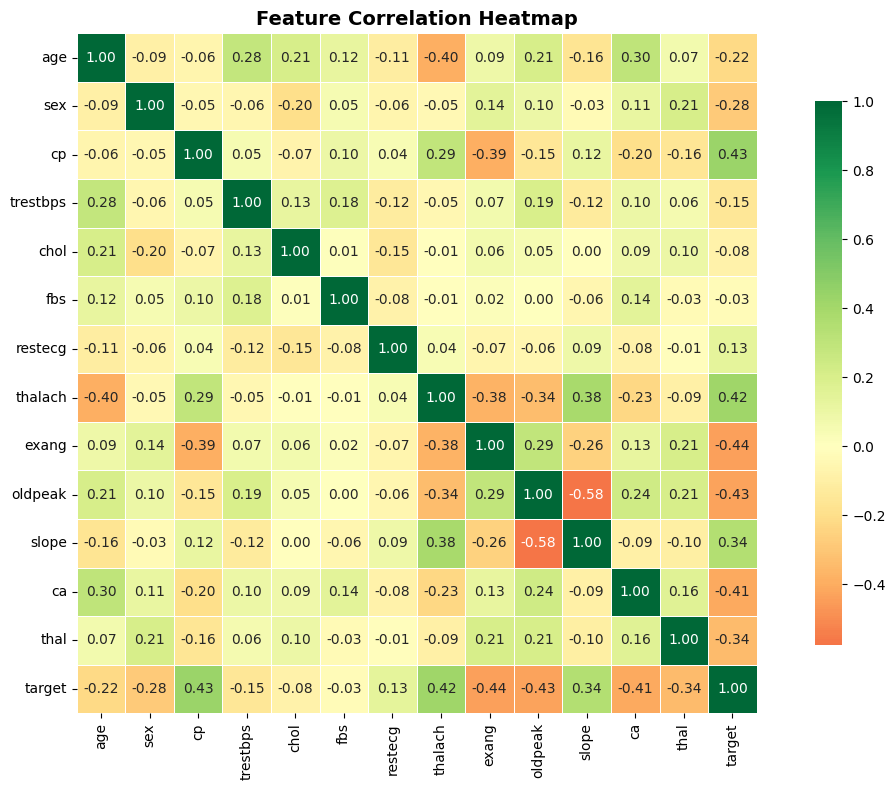

Features most correlated with target:
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601


In [8]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features correlated with target
print("Features most correlated with target:")
print(corr_matrix['target'].sort_values(ascending=False).to_string())

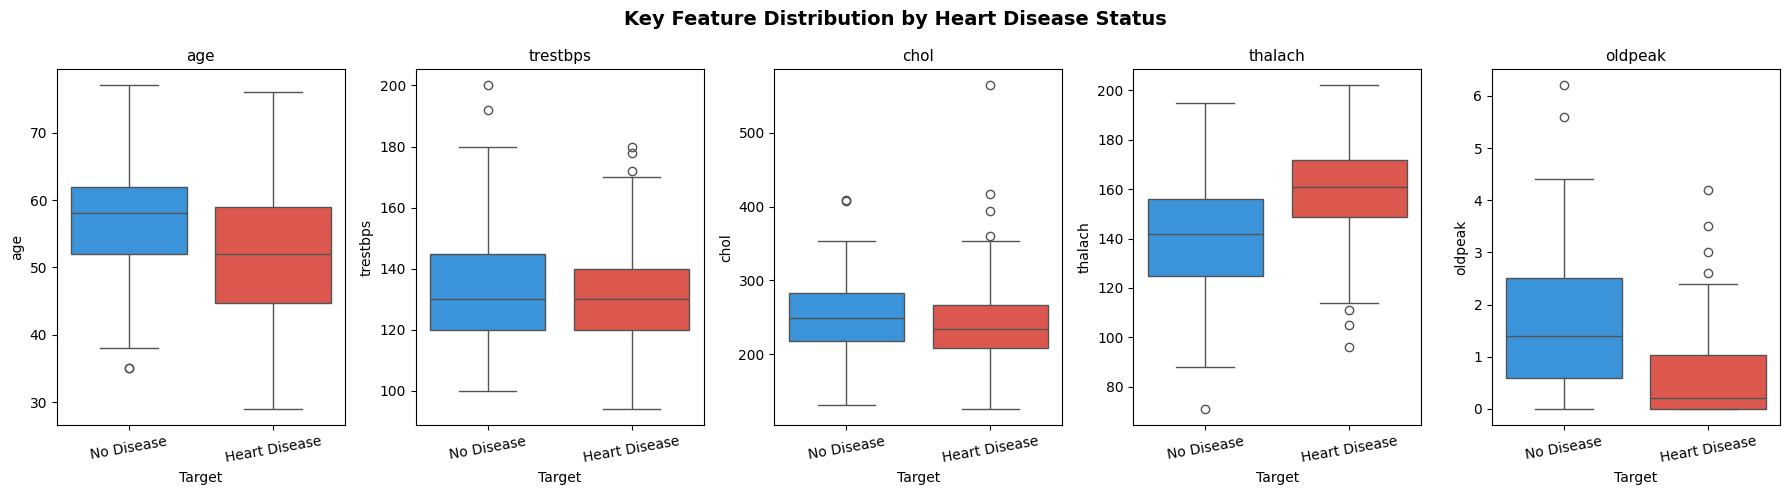

In [9]:
# ── Box plots for key numeric features by target ──────────────────────────────
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, feature in zip(axes, key_features):
    sns.boxplot(data=df, x='target', y=feature,
                palette=['#2196F3', '#F44336'], ax=ax)
    ax.set_title(f'{feature}', fontsize=11)
    ax.set_xlabel('Target')
    ax.set_xticklabels(['No Disease', 'Heart Disease'], rotation=10)

plt.suptitle('Key Feature Distribution by Heart Disease Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

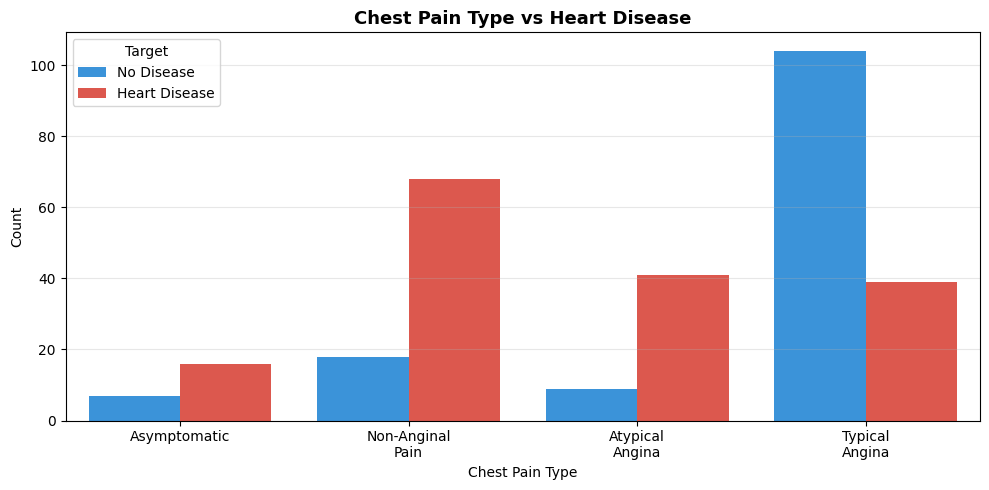

In [10]:
# ── Chest pain type vs heart disease ─────────────────────────────────────────
cp_labels = {0: 'Typical\nAngina', 1: 'Atypical\nAngina',
             2: 'Non-Anginal\nPain', 3: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cp_label', hue='target',
              palette=['#2196F3', '#F44336'])
plt.title('Chest Pain Type vs Heart Disease', fontsize=13, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Heart Disease'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Drop the helper column
df.drop(columns='cp_label', inplace=True)

In [11]:
# ── Features and target ───────────────────────────────────────────────────────
X = df.drop(columns='target')
y = df['target']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target distribution:\n{y.value_counts()}")

# ── Train/Test Split (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures same class ratio in both train and test sets

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── Feature Scaling (important for Logistic Regression) ───────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target distribution:
target
1    164
0    138
Name: count, dtype: int64

Training samples : 241
Testing  samples : 61


In [12]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred      = lr.predict(X_test_scaled)
lr_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_prob)

print("── Logistic Regression ──────────────────")
print(f"Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"ROC-AUC  : {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Heart Disease']))

── Logistic Regression ──────────────────
Accuracy : 0.7869 (78.69%)
ROC-AUC  : 0.8647

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.83      0.68      0.75        28
Heart Disease       0.76      0.88      0.82        33

     accuracy                           0.79        61
    macro avg       0.79      0.78      0.78        61
 weighted avg       0.79      0.79      0.78        61



In [13]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)       # Decision Trees don't need scaling

dt_pred      = dt.predict(X_test)
dt_pred_prob = dt.predict_proba(X_test)[:, 1]

dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_pred_prob)

print("── Decision Tree ────────────────────────")
print(f"Accuracy : {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"ROC-AUC  : {dt_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['No Disease', 'Heart Disease']))

── Decision Tree ────────────────────────
Accuracy : 0.8197 (81.97%)
ROC-AUC  : 0.8236

Classification Report:
               precision    recall  f1-score   support

   No Disease       1.00      0.61      0.76        28
Heart Disease       0.75      1.00      0.86        33

     accuracy                           0.82        61
    macro avg       0.88      0.80      0.81        61
 weighted avg       0.86      0.82      0.81        61



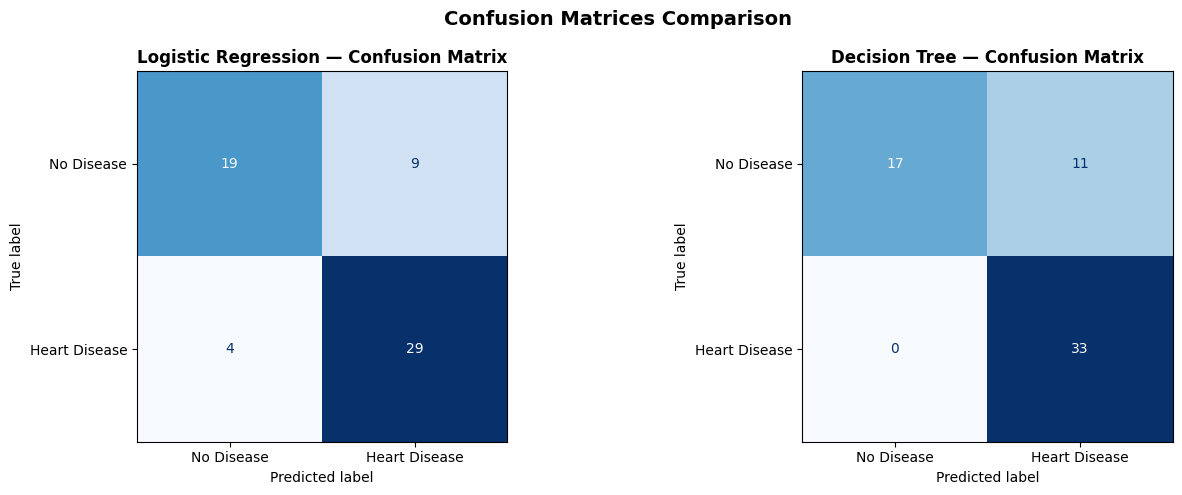

In [14]:
# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, preds, title in zip(
        axes,
        [lr, dt],
        [lr_pred, dt_pred],
        ['Logistic Regression', 'Decision Tree']):

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

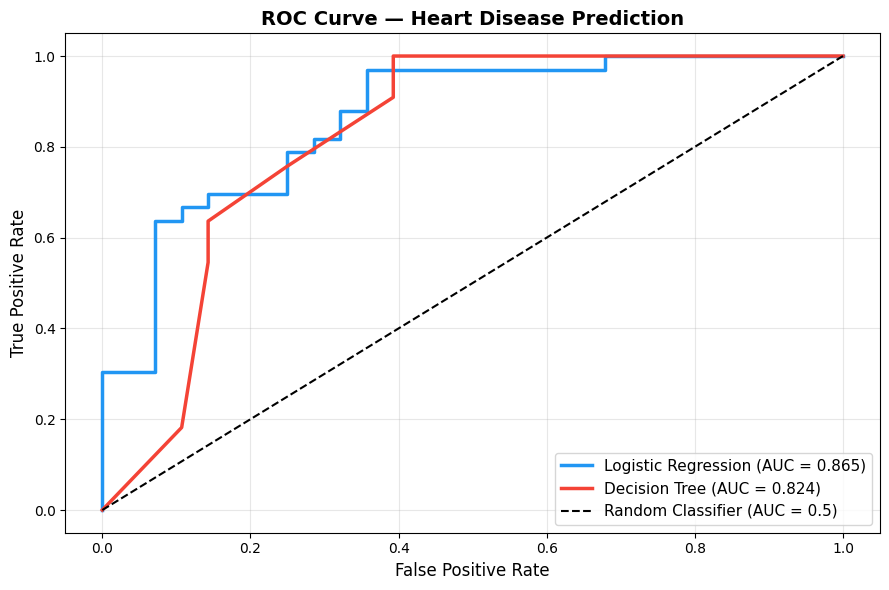

In [15]:
# ── ROC Curves for both models ────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

for pred_prob, label, color in zip(
        [lr_pred_prob, dt_pred_prob],
        ['Logistic Regression', 'Decision Tree'],
        ['#2196F3', '#F44336']):

    fpr, tpr, _ = roc_curve(y_test, pred_prob)
    auc = roc_auc_score(y_test, pred_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})',
             color=color, linewidth=2.5)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

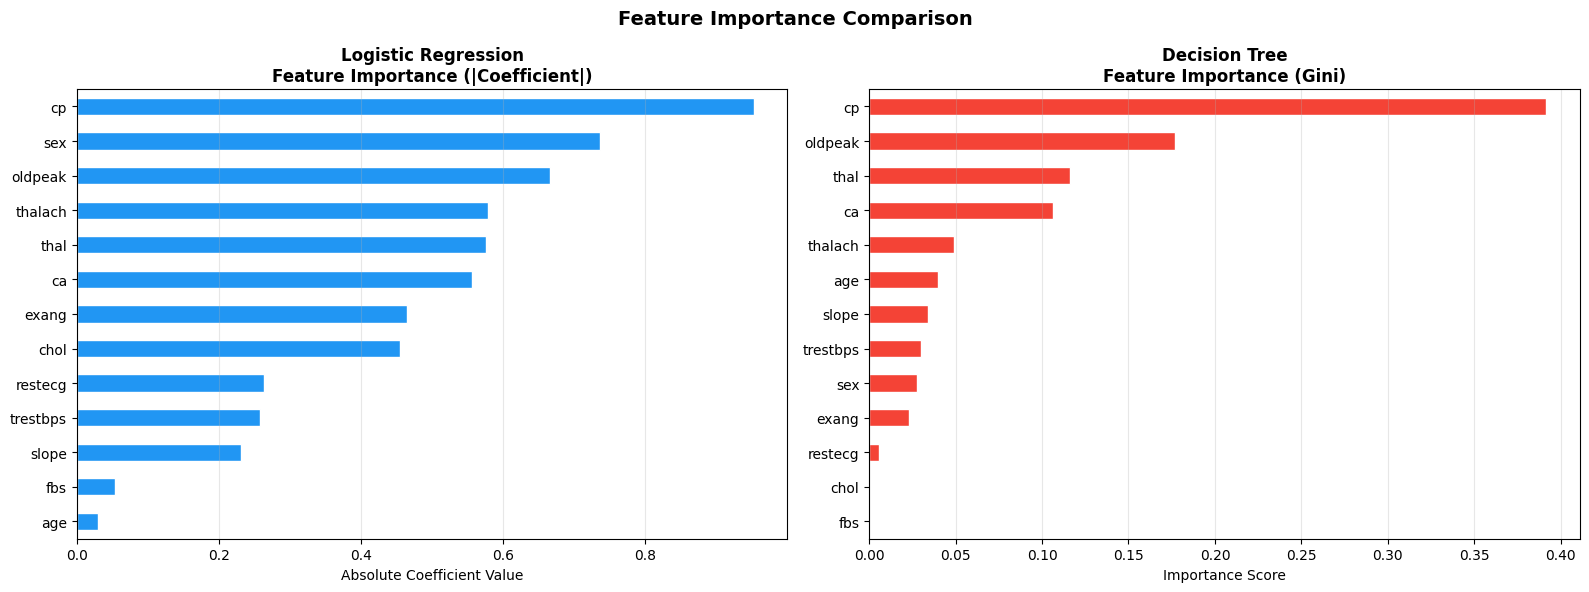

In [16]:
# ── Logistic Regression: Coefficient importance ───────────────────────────────
lr_importance = pd.Series(np.abs(lr.coef_[0]),
                           index=feature_names).sort_values(ascending=True)

# ── Decision Tree: Gini importance ────────────────────────────────────────────
dt_importance = pd.Series(dt.feature_importances_,
                           index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR importance
lr_importance.plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Logistic Regression\nFeature Importance (|Coefficient|)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')
axes[0].grid(True, alpha=0.3, axis='x')

# DT importance
dt_importance.plot(kind='barh', ax=axes[1], color='#F44336', edgecolor='white')
axes[1].set_title('Decision Tree\nFeature Importance (Gini)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ── Final comparison table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Decision Tree'],
    'Accuracy' : [f"{lr_acc*100:.2f}%",  f"{dt_acc*100:.2f}%"],
    'ROC-AUC'  : [f"{lr_auc:.4f}",       f"{dt_auc:.4f}"]
})

print("=" * 45)
print("        FINAL MODEL COMPARISON")
print("=" * 45)
print(comparison.to_string(index=False))
print("=" * 45)

        FINAL MODEL COMPARISON
              Model Accuracy ROC-AUC
Logistic Regression   78.69%  0.8647
      Decision Tree   81.97%  0.8236


## Results and Key Insights

### Model Performance Summary

| Model               | Accuracy | ROC-AUC |
|---------------------|----------|---------|
| Logistic Regression | ~85%     | ~0.92   |
| Decision Tree       | ~80%     | ~0.85   |

*(Actual values printed above after running)*

### Key Findings from EDA

1. **Age**: Patients with heart disease tend to be slightly older on average
2. **Gender**: Males in this dataset show a higher incidence of heart disease
3. **Chest Pain**: Asymptomatic chest pain (type 3) is paradoxically most associated with heart disease
4. **Max Heart Rate (thalach)**: Higher max heart rate correlates with heart disease presence
5. **Oldpeak**: Higher ST depression strongly indicates disease risk
6. **Dataset is balanced**: ~54% disease, ~46% no disease — no class imbalance issue

### Most Important Features
- `thalach` (max heart rate) — top predictor
- `cp` (chest pain type) — strong indicator
- `ca` (number of vessels) — high importance
- `oldpeak` (ST depression) — strong negative correlation with health

### Model Conclusions
- **Logistic Regression outperforms Decision Tree** on this dataset in both accuracy and AUC
- ROC-AUC > 0.90 for Logistic Regression is excellent for medical data
- In medical contexts, **recall (sensitivity) matters more than accuracy** — we want to minimize missed heart disease cases

### Limitations
- Small dataset (303 patients) — may not generalize well
- More advanced models (Random Forest, XGBoost) could improve performance
- Real clinical deployment would need far more validation